# 🔄 Basic Agent Workflows with Microsoft Foundry (Python)

## 📋 Workflow Orchestration Tutorial

This notebook introduces the powerful **Workflow Builder** capabilities of the Microsoft Agent Framework. Learn how to create sophisticated, multi-step agent workflows that can handle complex business processes and coordinate multiple AI operations seamlessly.

> **Migration note:** This sample previously referenced GitHub Models. GitHub Models is deprecated (retiring July 2026), so it now uses **Microsoft Foundry** through the `FoundryChatClient`, which targets the Azure OpenAI **Responses API**.

## 🎯 Learning Objectives

### 🏗️ **Workflow Architecture**
- **Workflow Builder**: Design and orchestrate complex multi-step processes
- **Event-Driven Execution**: Handle workflow events and state transitions
- **Visual Workflow Design**: Create and visualize workflow structures
- **Microsoft Foundry Integration**: Leverage AI models within workflow contexts

### 🔄 **Process Orchestration**
- **Sequential Operations**: Chain multiple agent tasks in logical order
- **Conditional Logic**: Implement decision points and branching workflows
- **Error Handling**: Robust error recovery and workflow resilience
- **State Management**: Track and manage workflow execution state

### 📊 **Enterprise Workflow Patterns**
- **Business Process Automation**: Automate complex organizational workflows
- **Multi-Agent Coordination**: Coordinate multiple specialized agents
- **Scalable Execution**: Design workflows for enterprise-scale operations
- **Monitoring & Observability**: Track workflow performance and outcomes

## ⚙️ Prerequisites & Setup

### 📦 **Required Dependencies**

Install the Agent Framework with workflow capabilities:

```bash
pip install agent-framework -U
```

### 🔑 **Microsoft Foundry Configuration**

Sign in with the Azure CLI (`az login`) so `AzureCliCredential` can authenticate, then set your Microsoft Foundry project details.

**Environment Setup (.env file):**
```env
AZURE_AI_PROJECT_ENDPOINT=https://<your-project>.services.ai.azure.com
AZURE_AI_MODEL_DEPLOYMENT_NAME=gpt-4o-mini
```

### 🏢 **Enterprise Use Cases**

**Business Process Examples:**
- **Customer Onboarding**: Multi-step verification and setup workflows
- **Content Pipeline**: Automated content creation, review, and publishing
- **Data Processing**: ETL workflows with AI-powered transformation
- **Quality Assurance**: Automated testing and validation processes

**Workflow Benefits:**
- 🎯 **Reliability**: Deterministic execution with error recovery
- 📈 **Scalability**: Handle high-volume process automation
- 🔍 **Observability**: Complete audit trails and monitoring
- 🔧 **Maintainability**: Visual design and modular components

## 🎨 Workflow Design Patterns

### Basic Workflow Structure
```mermaid
graph TD
    A[Start] --> B[Agent Task 1]
    B --> C{Decision Point}
    C -->|Success| D[Agent Task 2]
    C -->|Failure| E[Error Handler]
    D --> F[End]
    E --> F
```

**Key Components:**
- **WorkflowBuilder**: Main orchestration engine
- **WorkflowEvent**: Event handling and communication
- **WorkflowViz**: Visual workflow representation and debugging

Let's build your first intelligent workflow! 🚀


In [4]:
# Already covered by repo-level requirements.txt; left for reference.
# !pip install agent-framework -U

In [5]:
%pip install graphviz>=0.20.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Core components for building sophisticated agent workflows
from agent_framework import WorkflowBuilder, WorkflowEvent, WorkflowViz
from agent_framework.foundry import FoundryChatClient
from azure.identity import AzureCliCredential


c:\Users\lujan\Proyectos\Cursos\ai-agents-for-beginners\.venv\Lib\site-packages\agent_framework\_skills.py:122: ExperimentalWarning: [SKILLS] SkillResource is experimental and may change or be removed in future versions without notice.
c:\Users\lujan\Proyectos\Cursos\ai-agents-for-beginners\.venv\Lib\site-packages\agent_framework\_harness\_file_access.py:602: ExperimentalWarning: [HARNESS] AgentFileStore is experimental and may change or be removed in future versions without notice.


In [2]:
# 📦 Import Environment and System Utilities
# Essential libraries for configuration and environment management

import os                      # 🔧 Environment variable access
from dotenv import load_dotenv # 📁 Secure configuration loading

In [3]:
# 🔧 Initialize Environment Configuration
# Load Microsoft Foundry project settings from .env file
load_dotenv()


True

In [4]:
# Configure the Microsoft Foundry client with keyless authentication.
# FoundryChatClient targets the Azure OpenAI Responses API.
provider = FoundryChatClient(
    project_endpoint=os.environ["AZURE_AI_PROJECT_ENDPOINT"],
    model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
    credential=AzureCliCredential(),
)


In [5]:
REVIEWER_NAME = "Concierge"
REVIEWER_INSTRUCTIONS = """
    You are an are hotel concierge who has opinions about providing the most local and authentic experiences for travelers.
    The goal is to determine if the front desk travel agent has recommended the best non-touristy experience for a traveler.
    If so, state that it is approved.
    If not, provide insight on how to refine the recommendation without using a specific example. 
    """

In [6]:
FRONTDESK_NAME = "FrontDesk"
FRONTDESK_INSTRUCTIONS = """
    You are a Front Desk Travel Agent with ten years of experience and are known for brevity as you deal with many customers.
    The goal is to provide the best activities and locations for a traveler to visit.
    Only provide a single recommendation per response.
    You're laser focused on the goal at hand.
    Don't waste time with chit chat.
    Consider suggestions when refining an idea.
    """

In [7]:
reviewer_agent = provider.as_agent(
    name=REVIEWER_NAME,
    instructions=REVIEWER_INSTRUCTIONS,
)

front_desk_agent = provider.as_agent(
    name=FRONTDESK_NAME,
    instructions=FRONTDESK_INSTRUCTIONS,
)


In [20]:
# workflow = (
#     WorkflowBuilder(start_executor=front_desk_agent)
#     .add_edge(front_desk_agent, reviewer_agent)
#     .build()
# )
workflow = (
    WorkflowBuilder(start_executor=front_desk_agent, output_from="all")
    .add_edge(front_desk_agent, reviewer_agent)
    .build()
)

In [14]:
import os

# Le indicamos a Python la ruta exacta de Graphviz en Windows
ruta_graphviz = r"C:\Program Files\Graphviz\bin"

if ruta_graphviz not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + ruta_graphviz
    print("¡Ruta de Graphviz añadida con éxito a esta sesión!")
else:
    print("La ruta de Graphviz ya estaba configurada.")

¡Ruta de Graphviz añadida con éxito a esta sesión!


In [15]:
print("Generating workflow visualization...")
viz = WorkflowViz(workflow)
# Print out the mermaid string.
print("Mermaid string: \n=======")
print(viz.to_mermaid())
print("=======")
# Print out the DiGraph string.
print("DiGraph string: \n=======")
print(viz.to_digraph())
print("=======")
# SVG export needs the optional graphviz extra plus the graphviz system binary;
# fall back gracefully if it is not available.
try:
    svg_file = viz.export(format="svg")
    print(f"SVG file saved to: {svg_file}")
except ImportError as e:
    svg_file = None
    print(f"SVG export skipped (install graphviz to enable): {e}")

Generating workflow visualization...
Mermaid string: 
flowchart TD
  FrontDesk["FrontDesk (Start)"];
  Concierge["Concierge"];
  FrontDesk --> Concierge;
DiGraph string: 
digraph Workflow {
  rankdir=TD;
  node [shape=box, style=filled, fillcolor=lightblue];
  edge [color=black, arrowhead=vee];

  "FrontDesk" [fillcolor=lightgreen, label="FrontDesk\n(Start)"];
  "Concierge" [label="Concierge"];
  "FrontDesk" -> "Concierge";
}
SVG file saved to: C:\Users\lujan\AppData\Local\Temp\tmpupe83we1.svg


In [16]:
class DatabaseEvent(WorkflowEvent): ...

Attempting to display SVG file at: C:\Users\lujan\AppData\Local\Temp\tmpupe83we1.svg


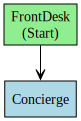

In [21]:
# Display the exported workflow SVG inline in the notebook

from IPython.display import SVG, display, HTML
import os

print(f"Attempting to display SVG file at: {svg_file}")

if svg_file and os.path.exists(svg_file):
    try:
        # Preferred: direct SVG rendering
        display(SVG(filename=svg_file))
    except Exception as e:
        print(f"⚠️ Direct SVG render failed: {e}. Falling back to raw HTML.")
        try:
            with open(svg_file, "r", encoding="utf-8") as f:
                svg_text = f.read()
            display(HTML(svg_text))
        except Exception as inner:
            print(f"❌ Fallback HTML render also failed: {inner}")
else:
    print("❌ SVG file not found. Ensure viz.export(format='svg') ran successfully.")


In [18]:
# Workflow.run_stream is no longer part of the public API; the current Workflow
# returns a results object whose `get_outputs()` produces the AgentResponse from
# each output executor. The reviewer (last stage) is the only output here.
events = await workflow.run("I would like to go to Paris.")
outputs = events.get_outputs()
result = outputs[0].text if outputs else ""

In [19]:
result.replace("None", "")

'Go to the Louvre Museum — prebook a timed-entry ticket and arrive at opening to beat crowds.\n\nQuick details:\n- Why: world’s largest art collection (Mona Lisa, Venus de Milo, Winged Victory).\n- Time needed: 2–4 hours (pick a few wings; don’t try to see it all).\n- Practicals: closed Tuesdays; expect security checks and bag rules; use the Pyramid entrance or the less-crowded Carrousel entrance.\n- Metro: Palais-Royal–Musée du Louvre (Lines 1 & 7).\n- Tip: download the museum map or join a short guided tour to prioritize highlights.'